In [1]:
# 1. Возвращаемся в корень Colab
%cd /content

# 2. Сносим старую папку со всеми потрохами намертво
!rm -rf /content/Pong-Game-Deep-Q-learning-RL-

# 3. Клонируем репозиторий с гитхаба С ЧИСТОГО ЛИСТА
!git clone https://github.com/egorzernin0305-rgb/Pong-Game-Deep-Q-learning-RL-.git

# 4. Переходим в новую чистую папку
%cd /content/Pong-Game-Deep-Q-learning-RL-

# 5. Ставим зависимости
!pip install -r requirements.txt

import numpy as np
from env_pong import PongEnv
from models import Baseline
from models import HumanPlayer
from models import DQN_StBaselines3
from models import MyDQN
import stable_baselines3
from stable_baselines3 import DQN
from mydqn_components import Q_network
import pandas as pd

/content
Cloning into 'Pong-Game-Deep-Q-learning-RL-'...
remote: Enumerating objects: 162, done.
remote: Counting objects: 100% (162/162), done.
remote: Compressing objects: 100% (133/133), done.
remote: Total 162 (delta 82), reused 68 (delta 25), pack-reused 0 (from 0)
Receiving objects: 100% (162/162), 4.88 MiB | 9.74 MiB/s, done.
Resolving deltas: 100% (82/82), done.
/content/Pong-Game-Deep-Q-learning-RL-
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.6/187.6 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 100.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 947.5/947.5 kB 59.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 123.6 MB/s eta 0:00:00


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
dqn_best = DQN.load("saved_models/pong_dqn_1.2M.zip")

In [ ]:
env_test = PongEnv(opponent=Baseline(),  render_mode = None , n_rounds=100)
agent = DQN_StBaselines3(model=dqn_best)
stats_st3 = env_test.demo(left_player=agent)

In [ ]:
for key, element in stats_st3.items():
    print(f"{key} - {element}")

avg_round_steps - 747.3219178082192
avg_round_time - 12.455365296803652
avg_round_reward - 1.5080136464945528
variance_reward - 4.858811679909693
score - {'agent': 46, 'opponent': 100}
agent_win_rate - 0.3150684931506849
rounds_amount - 146


In [ ]:
my_dqn = MyDQN(q_network=Q_network())
my_dqn.load("pong_mydqn_700k")
env_test_mydqn = PongEnv(opponent=Baseline(),  render_mode = 'human', n_rounds=100)
stats = env_test_mydqn.demo()

In [ ]:
# тут то что сейчас нужно

In [2]:
my_dqn = MyDQN(q_network=Q_network())
my_dqn.pretrain_on_dataset(pd.read_csv("pong_datasets/pong_dataset_100000.csv"), n_epoch=1)

0.6469792622598561 - loss on 1-th epoch


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
env_eval = PongEnv(opponent=Baseline(),  render_mode = None, n_rounds=100)

In [4]:
env_eval_100_rounds = PongEnv(opponent=Baseline(),  render_mode = None, n_rounds=300)
env_learning = PongEnv(opponent=Baseline(),  render_mode = None, n_rounds=100)
learning_stats = my_dqn.learn(total_timesteps= 2800000, env=env_learning, eval_env= env_eval_100_rounds)

прошло 100001 шагов
avg_round_steps - 233.80064308681673
avg_round_time - 3.8966773847802787
avg_round_reward - -0.7283330772214106
variance_reward - 0.36557468179616487
score - {'agent': 11, 'opponent': 300}
agent_win_rate - 0.03536977491961415
rounds_amount - 311
current loss - 0.0007198484963737428
прошло 200001 шагов
avg_round_steps - 199.0128617363344
avg_round_time - 3.316881028938907
avg_round_reward - -0.7700020047964683
variance_reward - 0.31190030811713104
score - {'agent': 11, 'opponent': 300}
agent_win_rate - 0.03536977491961415
rounds_amount - 311
current loss - 0.00024413061328232288
прошло 300001 шагов
avg_round_steps - 204.78896103896105
avg_round_time - 3.4131493506493507
avg_round_reward - -0.8130246185225805
variance_reward - 0.25113031227850663
score - {'agent': 8, 'opponent': 300}
agent_win_rate - 0.025974025974025976
rounds_amount - 308
current loss - 0.0005164995091035962
прошло 400001 шагов
avg_round_steps - 209.22727272727272
avg_round_time - 3.487121212121212


In [5]:
env_test = PongEnv(opponent=Baseline(),  render_mode = None, n_rounds=100)
stats_mydqn = env_test.demo(left_player=my_dqn)
for key, element in stats_mydqn.items():
    print(f"{key} - {element}")

avg_round_steps - 224.83809523809524
avg_round_time - 3.747301587301587
avg_round_reward - -0.6882293366414562
variance_reward - 0.44548688743962744
score - {'agent': 5, 'opponent': 100}
agent_win_rate - 0.047619047619047616
rounds_amount - 105


In [3]:
import torch
print(torch.cuda.is_available())

True


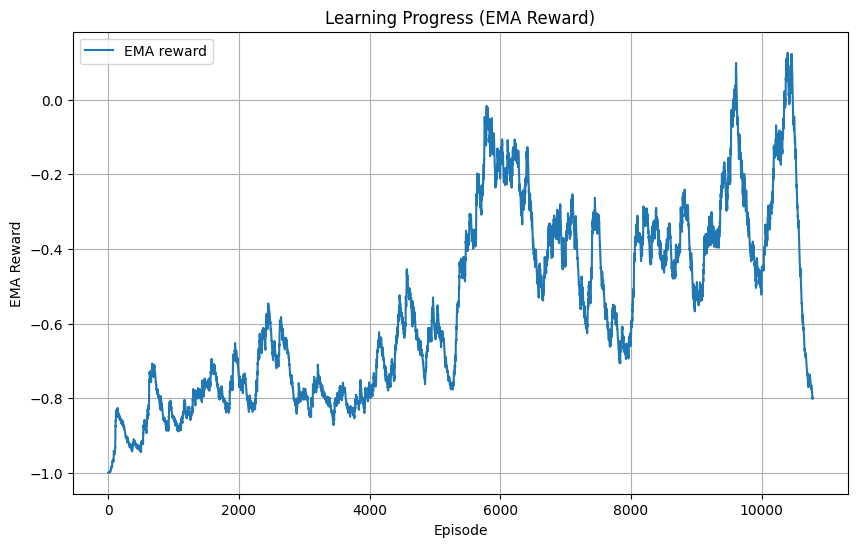

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(learning_stats, label='EMA reward')
plt.xlabel('Episode')
plt.ylabel('EMA Reward')
plt.title('Learning Progress (EMA Reward)')
plt.grid(True)
plt.legend()
plt.show()

In [8]:
from google.colab import files

for i in range(28):
  # Скачиваем на компьютер
  files.download(f"saved_models/pong_mydqn_rb150_{(i+1)*100000}_steps")

pd.DataFrame(learning_stats).to_csv("learning_stats_claude_rb150.csv", index=False)
files.download("learning_stats_claude_rb150.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

FileNotFoundError: Cannot find file: saved_models/pong_mydqn_rb150_2800000_steps

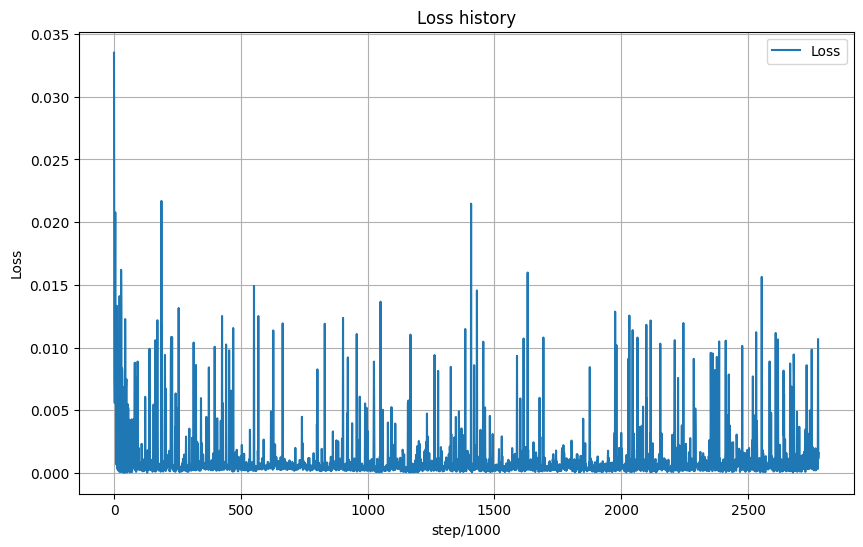

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [9]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(my_dqn.loss_history, label='Loss')
plt.xlabel('step/1000')
plt.ylabel('Loss')
plt.title('Loss history')
plt.grid(True)
plt.legend()
plt.show()
pd.DataFrame(my_dqn.loss_history).to_csv("loss_history_claude_015.csv", index=False)
files.download("loss_history_claude_015.csv")